In [17]:
import torch
torch_version = str(torch.__version__)
scatter_src = f"https://pytorch-geometric.com/whl/torch-{torch_version}.html"
sparse_src = f"https://pytorch-geometric.com/whl/torch-{torch_version}.html"
!pip install torch-scatter -f $scatter_src
!pip install torch-sparse -f $sparse_src
!pip install torch-geometric
!pip install pyg-lib
!pip install scikit-learn

Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2+cpu.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2+cpu.html


ERROR: Could not find a version that satisfies the requirement pyg-lib (from versions: none)
ERROR: No matching distribution found for pyg-lib


In [18]:
import torch
print(torch.__version__)
import torch_geometric
print(torch_geometric.__version__)

2.2.2+cpu
2.6.1


In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
from torch_geometric.nn import MessagePassing
from sklearn.model_selection import train_test_split
from torch_geometric.data import HeteroData

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_sparse import SparseTensor

class TemporalEncoding(nn.Module):
    """Sinusoidal temporal encoding for time-aware graph processing"""
    def __init__(self, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        # Fix: Ensure even hidden_size for sinusoidal encoding
        if hidden_size % 2 != 0:
            hidden_size = hidden_size + 1
        self.register_buffer('inv_freq', 1.0 / (10000 ** (torch.arange(0.0, hidden_size, 2.0) / hidden_size)))

    def forward(self, pos):
        # Fix: Handle device properly and dimension issues
        sinusoid_inp = pos.float().unsqueeze(-1) * self.inv_freq
        # Fix: Ensure output has correct hidden_size
        pos_emb = torch.cat([torch.sin(sinusoid_inp), torch.cos(sinusoid_inp)], dim=-1)
        return pos_emb[:, :self.hidden_size]  # Truncate to exact hidden_size

class CrossDatasetMetaLearner(nn.Module):

    def __init__(
        self,
        hidden_size,
        num_relations,
        num_datasets=1
    ):
        super().__init__()

        self.hidden_size = hidden_size

        self.meta_relation = nn.Embedding(
            num_relations,
            hidden_size
        )

        self.dataset_emb = nn.Embedding(
            num_datasets,
            hidden_size
        )

        self.meta_mlp = nn.Sequential(
            nn.Linear(
                hidden_size,
                hidden_size
            ),
            nn.ReLU(),
            nn.Linear(
                hidden_size,
                hidden_size * hidden_size
                + hidden_size
            )
        )

    def forward(
        self,
        relation_types,
        dataset_id
    ):

        rel_id = relation_types[0]

        rel_emb = self.meta_relation(
            rel_id
        )

        data_emb = self.dataset_emb(
            dataset_id
        )

        meta_input = (
            rel_emb + data_emb
        )

        params = self.meta_mlp(
            meta_input
        )

        weight_size = (
            self.hidden_size
            *
            self.hidden_size
        )

        weight = params[
            :weight_size
        ].view(
            self.hidden_size,
            self.hidden_size
        )

        bias = params[
            weight_size:
        ]

        return {
            'weight': weight,
            'bias': bias
        }
    
    
class HierarchicalAttention(nn.Module):
    """Two-level attention: edge-level and node-level attention"""
    def __init__(self, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        # Edge-level attention components
        self.edge_attn_linear = nn.Linear(hidden_size * 3, 1)  # src, dst, relation
        self.edge_attn_activation = nn.LeakyReLU(0.2)

        # Node-level attention components
        self.node_attn_linear = nn.Linear(hidden_size * 2, 1)  # aggregated_msg, self
        self.node_attn_activation = nn.LeakyReLU(0.2)

    def edge_level_attention(self, src_features, dst_features, relation_emb, time_emb):
        """Compute attention weights for each edge"""
        combined = torch.cat([src_features, dst_features, relation_emb + time_emb], dim=-1)
        edge_scores = self.edge_attn_linear(combined)
        edge_scores = self.edge_attn_activation(edge_scores)
        return torch.sigmoid(edge_scores)

    def node_level_attention(self, self_features, aggregated_messages):
        """Compute attention for combining different relation types"""
        combined = torch.cat([self_features, aggregated_messages], dim=-1)
        node_scores = self.node_attn_linear(combined)
        node_scores = self.node_attn_activation(node_scores)
        return torch.sigmoid(node_scores)

class DynamicMetaAttentionConv_Attn(nn.Module):
    """DMAHGT Convolution Layer with Dataset-Aware Meta Learning"""

    def __init__(
        self,
        in_channels,
        out_channels,
        hidden_size,
        num_relations
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_relations = num_relations

        # Relation Embeddings
        self.relation_emb = nn.Embedding(
            num_relations,
            hidden_size
        )

        # Temporal Encoding
        self.temporal_encoding = TemporalEncoding(
            hidden_size
        )

        # Cross-Dataset Meta Learner
        self.meta_learner = CrossDatasetMetaLearner(
            hidden_size,
            num_relations,
            num_datasets=1
        )

        # Hierarchical Attention
        self.hierarchical_attention = (
            HierarchicalAttention(
                hidden_size
            )
        )

        # Feature Transformations
        self.src_transform = nn.Linear(
            in_channels,
            hidden_size
        )

        self.dst_transform = nn.Linear(
            in_channels,
            hidden_size
        )

        self.output_transform = nn.Linear(
            hidden_size,
            out_channels
        )

        self.layer_norm = nn.LayerNorm(
            hidden_size
        )

    def forward(
        self,
        src_x,
        dst_x,
        edge_index,
        edge_type,
        edge_time,
        dataset_id
    ):

        # =====================================
        # Relation Embeddings
        # =====================================
        rel_emb = self.relation_emb(
            edge_type
        )

        # =====================================
        # Temporal Encoding
        # =====================================
        if edge_time is not None:

            time_emb = self.temporal_encoding(
                edge_time.float()
            )

        else:

            time_emb = torch.zeros(
                rel_emb.size(0),
                self.hidden_size,
                device=src_x.device
            )

        # =====================================
        # Dataset-Aware Meta Learning
        # =====================================
        meta_params = self.meta_learner(
            edge_type,
            dataset_id
        )

        # =====================================
        # Node Feature Transformations
        # =====================================
        src_transformed = (
            self.src_transform(src_x)
        )

        dst_transformed = (
            self.dst_transform(dst_x)
        )

        # =====================================
        # Tensor / SparseTensor Support
        # =====================================
        if isinstance(
            edge_index,
            SparseTensor
        ):

            row, col, _ = edge_index.coo()

            src_nodes = src_transformed[
                row
            ]

            dst_nodes = dst_transformed[
                col
            ]

            target_indices = col

        else:

            src_nodes = src_transformed[
                edge_index[0]
            ]

            dst_nodes = dst_transformed[
                edge_index[1]
            ]

            target_indices = edge_index[1]

        # =====================================
        # Edge-Level Attention
        # =====================================
        edge_weights = (
            self.hierarchical_attention
            .edge_level_attention(
                src_nodes,
                dst_nodes,
                rel_emb,
                time_emb
            )
        )

        # =====================================
        # Dynamic Relation Parameters
        # =====================================
        weight = meta_params['weight']
        bias = meta_params['bias']

        transformed_src = (
            src_nodes @ weight
        ) + bias

        # =====================================
        # Attention-Weighted Messages
        # =====================================
        weighted_messages = (
            transformed_src
            * edge_weights
        )

        # =====================================
        # Message Aggregation
        # =====================================
        aggregated = torch.zeros_like(
            dst_transformed
        )

        aggregated.index_add_(
            0,
            target_indices,
            weighted_messages
        )

        # =====================================
        # Node-Level Attention
        # =====================================
        node_weights = (
            self.hierarchical_attention
            .node_level_attention(
                dst_transformed,
                aggregated
            )
        )

        # =====================================
        # Residual Aggregation
        # =====================================
        output = (
            dst_transformed
            +
            aggregated
            * node_weights
        )

        # =====================================
        # LayerNorm
        # =====================================
        output = self.layer_norm(
            output
        )

        # =====================================
        # Output Projection
        # =====================================
        output = self.output_transform(
            output
        )

        return output


class DMA_HGT(nn.Module):

    def __init__(self, hetero_graph, args):
        super().__init__()

        self.hidden_size = args['hidden_size']
        self.num_layers = args['num_layers']
        self.dropout = args['dropout']
        self.device = args['device']

        # Dataset ID (MovieLens = 0)
        self.dataset_id = torch.tensor(
            0,
            dtype=torch.long,
            device=self.device
        )

        # ==========================
        # Node Embeddings
        # ==========================
        self.node_emb = nn.ModuleDict()

        for node_type in hetero_graph.node_types:
            self.node_emb[node_type] = nn.Linear(
                hetero_graph[node_type].x.shape[1],
                self.hidden_size
            ).to(self.device)

        # ==========================
        # Relation Types
        # ==========================
        self.relation_types = sorted(
            list(
                set(
                    [
                        edge_type[1]
                        for edge_type in hetero_graph.edge_types
                    ]
                )
            )
        )

        self.relation_dict = {
            rel: idx
            for idx, rel in enumerate(
                self.relation_types
            )
        }

        # ==========================
        # DMAHGT Layers
        # ==========================
        self.convs = nn.ModuleList()

        for _ in range(self.num_layers):

            self.convs.append(
                DynamicMetaAttentionConv_Attn(
                    self.hidden_size,
                    self.hidden_size,
                    self.hidden_size,
                    num_relations=len(
                        self.relation_types
                    )
                ).to(self.device)
            )

        # ==========================
        # LayerNorm
        # ==========================
        self.temporal_norm = nn.LayerNorm(
            self.hidden_size
        ).to(self.device)

        # ==========================
        # Explainability
        # ==========================
        self.importance_proj = nn.Linear(
            self.hidden_size,
            1
        ).to(self.device)

    # ==========================================
    # Link Prediction Decoder
    # ==========================================
    def decode(
        self,
        user_emb,
        movie_emb,
        edge_index
    ):

        src = user_emb[
            edge_index[0]
        ]

        dst = movie_emb[
            edge_index[1]
        ]

        return (
            src * dst
        ).sum(dim=1)

    # ==========================================
    # Forward
    # ==========================================
    def forward(
        self,
        node_features,
        edge_indices,
        edge_timestamps=None
    ):

        x = {}

        for node_type, feat in node_features.items():

            x[node_type] = (
                self.node_emb[node_type](
                    feat.to(self.device)
                )
            )

        for conv in self.convs:

            x_new = {}

            for (
                message_type,
                edge_index
            ) in edge_indices.items():

                src_type, rel_type, dst_type = (
                    message_type
                )

                if isinstance(
                    edge_index,
                    SparseTensor
                ):

                    nnz = edge_index.nnz()
                    edge_index_tensor = edge_index

                else:

                    nnz = edge_index.size(1)
                    edge_index_tensor = edge_index

                rel_idx = torch.full(
                    (nnz,),
                    self.relation_dict[
                        rel_type
                    ],
                    dtype=torch.long,
                    device=self.device
                )

                if (
                    edge_timestamps is not None
                    and message_type in edge_timestamps
                ):

                    edge_time = (
                        edge_timestamps[
                            message_type
                        ].to(
                            self.device
                        )
                    )

                else:

                    edge_time = torch.zeros(
                        nnz,
                        dtype=torch.float,
                        device=self.device
                    )

                out = conv(
                    src_x=x[src_type],
                    dst_x=x[dst_type],
                    edge_index=edge_index_tensor,
                    edge_type=rel_idx,
                    edge_time=edge_time,
                    dataset_id=self.dataset_id
                )

                if dst_type not in x_new:

                    x_new[dst_type] = out

                else:

                    x_new[dst_type] += out

            for node_type in x:

                if node_type in x_new:

                    x[node_type] = (
                        self.temporal_norm(
                            x[node_type]
                            +
                            x_new[node_type]
                        )
                    )

                x[node_type] = F.dropout(
                    x[node_type],
                    p=self.dropout,
                    training=self.training
                )

        importance = {}

        for node_type in x:

            importance[node_type] = (
                self.importance_proj(
                    x[node_type]
                )
            )

        return x, importance

In [21]:
import torch.optim as optim
def setup_optimizer_and_scheduler(configuration, model_params):
    weight_decay = configuration.weight_decay
    trainable_params = filter(lambda p: p.requires_grad, model_params)

    if configuration.optimizer == 'adam':
        optimizer = torch.optim.Adam(trainable_params, lr=configuration.learning_rate, weight_decay=weight_decay)
    elif configuration.optimizer == 'sgd':
        optimizer = torch.optim.SGD(trainable_params, lr=configuration.learning_rate, momentum=0.95, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.Adam(trainable_params, lr=configuration.learning_rate, weight_decay=weight_decay)
        
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=max(1, configuration.epochs),eta_min=1e-6)

    return scheduler, optimizer      

## Training and Testing

In [22]:
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import torch
import numpy as np
from torch_geometric.data import HeteroData
import requests
import zipfile
import io
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm import trange
import torch
import torch.nn.functional as F
from torch_geometric.utils import negative_sampling
from sklearn.model_selection import train_test_split
import numpy as np

def download_and_extract_movielens():
    """Download MovieLens 100K dataset and extract it"""

    print("Downloading MovieLens 100K dataset...")

    url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
    response = requests.get(url, timeout=60)

    if response.status_code != 200:
        raise Exception(f"Failed to download dataset: HTTP {response.status_code}")

    extract_path = 'movielens'
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)

    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        zip_ref.extractall(extract_path)

    print("Dataset downloaded and extracted successfully!")

    extracted_folder = os.path.join(extract_path, 'ml-100k')

    if os.path.exists(extracted_folder):
        print(f"Files extracted to: {extracted_folder}")
        return extracted_folder
    else:
        return extract_path


def encode_user_features(users_df):
    """Encode user features for MovieLens 100K"""

    print("User data info:")
    print(f"  Age range: {users_df['Age'].min()} - {users_df['Age'].max()}")

    # Gender
    gender = torch.tensor(
        [0 if g == 'M' else 1 for g in users_df['Gender']],
        dtype=torch.float
    ).unsqueeze(1)

    # Age (Min-Max normalization)
    age = torch.tensor(
        users_df['Age'].values,
        dtype=torch.float
    ).unsqueeze(1)

    age = (age - age.min()) / (age.max() - age.min())

    # Occupation
    occupations = users_df['Occupation'].astype('category')

    occupation_codes = torch.tensor(
        occupations.cat.codes.values,
        dtype=torch.long
    )

    num_occupations = len(occupations.cat.categories)

    occupation_onehot = F.one_hot(
        occupation_codes,
        num_classes=num_occupations
    ).float()

    # Combine features
    user_features = torch.cat(
        [
            gender,
            age,
            occupation_onehot
        ],
        dim=1
    )

    print(f"  Number of occupations: {num_occupations}")
    print(f"  User feature dimension: {user_features.shape[1]}")

    return user_features


def encode_movie_features(movies_df):
    """Encode MovieLens 100K movie genres"""

    genre_columns = [
        'unknown',
        'Action',
        'Adventure',
        'Animation',
        "Children's",
        'Comedy',
        'Crime',
        'Documentary',
        'Drama',
        'Fantasy',
        'Film-Noir',
        'Horror',
        'Musical',
        'Mystery',
        'Romance',
        'Sci-Fi',
        'Thriller',
        'War',
        'Western'
    ]

    print("Movie data info:")
    print(f"  Total genres: {len(genre_columns)}")

    movie_features = torch.tensor(
        movies_df[genre_columns].values,
        dtype=torch.float
    )

    print(f"  Movie feature dimension: {movie_features.shape[1]}")

    return movie_features

def load_movielens_heterogeneous(data_path, use_features=True, use_temporal=True):
    """Load MovieLens dataset with real features and timestamps"""
    
    print(f"Loading MovieLens dataset from: {data_path}")
    
    print("\nAvailable files in directory:")
    try:
        for f in os.listdir(data_path):
            print(f"  - {f}")
    except:
        print("  Could not list directory contents")
    
    # Load files
    try:
        users_df = pd.read_csv(
            os.path.join(data_path, 'u.user'),
            sep='|',
            names=['UserID','Age','Gender','Occupation','Zip'],
            encoding='latin-1'
        )
        print(f"✓ Loaded u.user: {len(users_df)} records")
    except Exception as e:
        print(f"✗ u.user not found or error: {e}")
        raise

    try:
        movie_cols = [
            'MovieID','Title','ReleaseDate','VideoReleaseDate',
            'IMDbURL',
            'unknown','Action','Adventure','Animation',
            "Children's",'Comedy','Crime','Documentary',
            'Drama','Fantasy','Film-Noir','Horror',
            'Musical','Mystery','Romance','Sci-Fi',
            'Thriller','War','Western'
        ]

        
        movies_df = pd.read_csv(
            os.path.join(data_path,'u.item'),
            sep='|',
            names=movie_cols,
            encoding='latin-1',
            engine='python'
        )
        print(f"✓ Loaded u.item: {len(movies_df)} records")
    except Exception as e:
        print(f"✗ u.item not found or error: {e}")
        raise

    try:
        ratings_df = pd.read_csv(
            os.path.join(data_path,'u.data'),
            sep='\t',
            names=['UserID','MovieID','Rating','Timestamp'],
            engine='python'
        )
        print(f"✓ Loaded u.data: {len(ratings_df)} records")
    except Exception as e:
        print(f"✗ u.data not found or error: {e}")
        raise

    # Create HeteroData
    data = HeteroData()

    # Unique users & movies
    all_users = set(users_df['UserID']).union(set(ratings_df['UserID']))
    all_movies = set(movies_df['MovieID']).union(set(ratings_df['MovieID']))
    
    num_users = len(all_users)
    num_movies = len(all_movies)

    user_id_to_idx = {uid: i for i, uid in enumerate(sorted(all_users))}
    movie_id_to_idx = {mid: i for i, mid in enumerate(sorted(all_movies))}

    print(f"\nStatistics - Users: {num_users}, Movies: {num_movies}")

    # Encode features
    user_feat_dim = 0
    movie_feat_dim = 0
    
    if use_features:
        # Sort dataframes consistently
        users_df_sorted = users_df.sort_values('UserID').reset_index(drop=True)
        
        # Verify alignment
        expected_users = sorted(all_users)
        actual_users = users_df_sorted['UserID'].tolist()
        
        if expected_users != actual_users:
            print(f"Warning: User ID mismatch! Reindexing...")
            user_id_to_df_idx = {uid: i for i, uid in enumerate(users_df_sorted['UserID'])}
            reorder_indices = [user_id_to_df_idx[uid] for uid in expected_users]
            users_df_sorted = users_df_sorted.iloc[reorder_indices].reset_index(drop=True)
        
        user_features = encode_user_features(users_df_sorted)
        user_feat_dim = user_features.shape[1]
        
        movies_df_sorted = movies_df.sort_values('MovieID').reset_index(drop=True)
        
        # Verify alignment
        expected_movies = sorted(all_movies)
        actual_movies = movies_df_sorted['MovieID'].tolist()
        
        if expected_movies != actual_movies:
            print(f"Warning: Movie ID mismatch! Reindexing...")
            movie_id_to_df_idx = {mid: i for i, mid in enumerate(movies_df_sorted['MovieID'])}
            reorder_indices = [movie_id_to_df_idx[mid] for mid in expected_movies]
            movies_df_sorted = movies_df_sorted.iloc[reorder_indices].reset_index(drop=True)
        
        movie_features = encode_movie_features(movies_df_sorted)
        movie_feat_dim = movie_features.shape[1]
        
        print(f"\nFeature dimensions:")
        print(f"  User features: {user_feat_dim} dims")
        print(f"  Movie features: {movie_feat_dim} dims")
        
        data['user'].x = user_features
        data['movie'].x = movie_features
    

    data['user'].num_nodes = num_users
    data['movie'].num_nodes = num_movies

    # ============================
    # Edges: User → Movie (ratings) - UPDATED VERSION
    # ============================
    edge_index = []
    edge_weight = []
    timestamps = []

    valid_edges = 0
    skipped_users = set()
    skipped_movies = set()

    for _, row in ratings_df.iterrows():
        u = row['UserID']
        m = row['MovieID']

        if u in user_id_to_idx and m in movie_id_to_idx:
            edge_index.append([user_id_to_idx[u], movie_id_to_idx[m]])
            edge_weight.append(float(row['Rating']))
            if use_temporal:
                timestamps.append(float(row['Timestamp']))
            valid_edges += 1
        else:
            if u not in user_id_to_idx:
                skipped_users.add(u)
            if m not in movie_id_to_idx:
                skipped_movies.add(m)

    print(f"User-rates-movie relations: {valid_edges}")
    
    if skipped_users:
        print(f"  Skipped {len(skipped_users)} users not in user list")
    if skipped_movies:
        print(f"  Skipped {len(skipped_movies)} movies not in movie list")

    if edge_index:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight, dtype=torch.float)
        
        # Process timestamps if using temporal features
        timestamps_tensor = None
        if use_temporal and timestamps:
            # Normalize timestamps to [0, 1] range
            timestamps_tensor = torch.tensor(timestamps, dtype=torch.float)
            if timestamps_tensor.max() > timestamps_tensor.min():
                timestamps_tensor = (timestamps_tensor - timestamps_tensor.min()) / (timestamps_tensor.max() - timestamps_tensor.min())
            else:
                timestamps_tensor = torch.zeros_like(timestamps_tensor)

        data['user', 'rates', 'movie'].edge_index = edge_index
        data['user', 'rates', 'movie'].weight = edge_weight
        
        data['movie', 'rev_rates', 'user'].edge_index = edge_index.flip(0)
        data['movie', 'rev_rates', 'user'].weight = edge_weight
        
        # Only assign timestamp if we actually have temporal data
        if use_temporal and timestamps_tensor is not None:
            data['user', 'rates', 'movie'].timestamp = timestamps_tensor
            data['movie', 'rev_rates', 'user'].timestamp = timestamps_tensor

        data['user', 'rates', 'movie'].original_edge_index = edge_index.clone()

    print(f"\nFINAL STATISTICS:")
    print(f"  Users: {data['user'].num_nodes}")
    print(f"  Movies: {data['movie'].num_nodes}")
    print(f"  User→Movie edges: {valid_edges}")
    print(f"  User feature dimension: {user_feat_dim}")
    print(f"  Movie feature dimension: {movie_feat_dim}")
    if use_temporal:
        print(f"  Temporal information: enabled")

    return data, user_feat_dim, movie_feat_dim



def train_link_prediction_model(data, model, configuration):
    optimizer = optim.Adam(
        model.parameters(),
        lr=configuration.learning_rate,
        weight_decay=configuration.weight_decay
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=configuration.epochs,
        eta_min=1e-6
    )

    losses = []
    val_aucs = []

    best_val_auc = 0.0
    best_model_state = None

    num_epochs = configuration.epochs

    for epoch in trange(num_epochs, desc="DMAHGT Training"):

        model.train()
        optimizer.zero_grad()

        node_features = {
            node_type: data[node_type].x
            for node_type in data.node_types
        }

        edge_indices = {
            edge_type: data[edge_type].edge_index
            for edge_type in data.edge_types
        }

        edge_timestamps = {}

        for edge_type in data.edge_types:
            if 'timestamp' in data[edge_type]:
                edge_timestamps[edge_type] = data[edge_type].timestamp

        z, importance = model(
            node_features,
            edge_indices,
            edge_timestamps
        )

        user_emb = z['user']
        movie_emb = z['movie']

        pos_edge_index = data.train_pos_edge_index
        num_pos = pos_edge_index.size(1)

        neg_edge_index = negative_sampling(
            edge_index=pos_edge_index,
            num_nodes=(
                data['user'].num_nodes,
                data['movie'].num_nodes
            ),
            num_neg_samples=num_pos
        )

        pos_pred = model.decode(
            user_emb,
            movie_emb,
            pos_edge_index
        )

        neg_pred = model.decode(
            user_emb,
            movie_emb,
            neg_edge_index
        )

        pos_loss = -torch.log(
            torch.sigmoid(pos_pred) + 1e-15
        ).mean()

        neg_loss = -torch.log(
            1 - torch.sigmoid(neg_pred) + 1e-15
        ).mean()

        loss = pos_loss + neg_loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        scheduler.step()

        losses.append(loss.item())

        if epoch % 5 == 0:

            model.eval()

            with torch.no_grad():

                z, importance = model(
                    node_features,
                    edge_indices,
                    edge_timestamps
                )

                user_emb = z['user']
                movie_emb = z['movie']

                val_pred = model.decode(
                    user_emb,
                    movie_emb,
                    data.val_edge_index
                )

                val_pred = torch.sigmoid(val_pred)

                val_auc = roc_auc_score(
                    data.val_edge_label.cpu().numpy(),
                    val_pred.cpu().numpy()
                )

                val_aucs.append(val_auc)

                if val_auc > best_val_auc:

                    best_val_auc = val_auc

                    best_model_state = {
                        k: v.cpu().clone()
                        for k, v in model.state_dict().items()
                    }

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()

    with torch.no_grad():

        node_features = {
            node_type: data[node_type].x
            for node_type in data.node_types
        }

        edge_indices = {
            edge_type: data[edge_type].edge_index
            for edge_type in data.edge_types
        }

        edge_timestamps = {}

        for edge_type in data.edge_types:
            if 'timestamp' in data[edge_type]:
                edge_timestamps[edge_type] = data[edge_type].timestamp

        z, importance = model(
            node_features,
            edge_indices,
            edge_timestamps
        )

        user_emb = z['user']
        movie_emb = z['movie']

        test_pred = model.decode(
            user_emb,
            movie_emb,
            data.test_edge_index
        )

        test_pred = torch.sigmoid(test_pred)

        test_auc = roc_auc_score(
            data.test_edge_label.cpu().numpy(),
            test_pred.cpu().numpy()
        )

        test_ap = average_precision_score(
            data.test_edge_label.cpu().numpy(),
            test_pred.cpu().numpy()
        )

    test_metrics = {
        'auc': test_auc,
        'ap': test_ap
    }

    return (
        val_aucs,
        losses,
        model,
        test_metrics
    )

def evaluate_recommendation_clean(
    model,
    data,
    k_list=[5, 10, 20]
):
    """
    Fast recommendation evaluation
    Computes:
    HR@K
    NDCG@K
    MRR
    """

    model.eval()

    HR = {
        k: []
        for k in k_list
    }

    NDCG = {
        k: []
        for k in k_list
    }

    MRR = []

    with torch.no_grad():

        # =====================================
        # Generate embeddings
        # =====================================
        node_features = {
            node_type: data[node_type].x
            for node_type in data.node_types
        }

        edge_indices = {
            edge_type: data[edge_type].edge_index
            for edge_type in data.edge_types
        }

        edge_timestamps = {}

        for edge_type in data.edge_types:

            if 'timestamp' in data[edge_type]:

                edge_timestamps[edge_type] = (
                    data[edge_type].timestamp
                )

        z, _ = model(
            node_features,
            edge_indices,
            edge_timestamps
        )

        user_emb = z['user']
        movie_emb = z['movie']

        # =====================================
        # Positive Test Edges
        # =====================================
        pos_edges = data.test_edge_index[
            :,
            data.test_edge_label == 1
        ]

        if pos_edges.size(1) == 0:

            print(
                "Warning: No positive test edges."
            )

            results = {}

            for k in k_list:

                results[f'HR@{k}'] = 0
                results[f'NDCG@{k}'] = 0

            results['MRR'] = 0

            return results

        # =====================================
        # Evaluate only subset
        # =====================================
        max_eval_edges = 5000

        if pos_edges.size(1) > max_eval_edges:

            eval_idx = np.random.choice(
                pos_edges.size(1),
                max_eval_edges,
                replace=False
            )

            pos_edges = pos_edges[
                :,
                eval_idx
            ]

        # =====================================
        # Build user history lookup
        # =====================================
        user_positive_items = {}

        edge_sets = [
            (
                data.train_edge_index,
                data.train_edge_label
            )
        ]
            

        for edge_index, edge_label in edge_sets:

            positive_edges = edge_index[
                :,
                edge_label == 1
            ]

            for i in range(
                positive_edges.size(1)
            ):

                u = positive_edges[
                    0,
                    i
                ].item()

                m = positive_edges[
                    1,
                    i
                ].item()

                if u not in user_positive_items:

                    user_positive_items[u] = set()

                user_positive_items[u].add(m)

        # =====================================
        # Movie Set
        # =====================================
        all_movies = set(
            range(
                data['movie'].num_nodes
            )
        )

        # =====================================
        # Evaluate
        # =====================================
        for edge in pos_edges.t():

            user = edge[0].item()
            pos_movie = edge[1].item()

            user_seen = (
                user_positive_items.get(
                    user,
                    set()
                )
            )

            candidate_movies = list(
                all_movies - user_seen
            )

            if len(candidate_movies) < 49:
                continue

            neg_movies = np.random.choice(
                candidate_movies,
                69,
                replace=False
            )

            candidates = (
                list(neg_movies)
                + [pos_movie]
            )

            users = torch.full(
                (
                    len(candidates),
                ),
                user,
                dtype=torch.long,
                device=user_emb.device
            )

            movies = torch.tensor(
                candidates,
                dtype=torch.long,
                device=user_emb.device
            )

            edge_index = torch.stack(
                [
                    users,
                    movies
                ]
            )

            scores = model.decode(
                user_emb,
                movie_emb,
                edge_index
            )

            scores = (
                scores
                .cpu()
                .numpy()
            )

            ranking = np.argsort(
                scores
            )[::-1]

            ranked_movies = [
                candidates[i]
                for i in ranking
            ]

            for k in k_list:

                if pos_movie in ranked_movies[:k]:

                    HR[k].append(1)

                    rank = (
                        ranked_movies.index(
                            pos_movie
                        )
                        + 1
                    )

                    NDCG[k].append(
                        1
                        /
                        np.log2(rank + 1)
                    )

                else:

                    HR[k].append(0)
                    NDCG[k].append(0)

            rank = (
                ranked_movies.index(
                    pos_movie
                )
                + 1
            )

            MRR.append(
                1.0 / rank
            )

    # =====================================
    # Final Metrics
    # =====================================
    results = {}

    for k in k_list:

        results[f'HR@{k}'] = (
            np.mean(HR[k])
            if len(HR[k]) > 0
            else 0
        )

        results[f'NDCG@{k}'] = (
            np.mean(NDCG[k])
            if len(NDCG[k]) > 0
            else 0
        )

    results['MRR'] = (
        np.mean(MRR)
        if len(MRR) > 0
        else 0
    )

    return results


class Config:
    def __init__(self, parameters):
        self.__dict__.update(parameters)

In [23]:
from torch_geometric.utils import negative_sampling

def prepare_link_prediction_data(
    data,
    val_ratio=0.1,
    test_ratio=0.1
):

    edge_index = data['user', 'rates', 'movie'].edge_index

    num_edges = edge_index.size(1)

    perm = torch.randperm(num_edges)

    num_val = int(num_edges * val_ratio)
    num_test = int(num_edges * test_ratio)
    num_train = num_edges - num_val - num_test

    train_idx = perm[:num_train]
    val_idx = perm[num_train:num_train + num_val]
    test_idx = perm[num_train + num_val:]

    train_pos_edge_index = edge_index[:, train_idx]
    val_pos_edge_index = edge_index[:, val_idx]
    test_pos_edge_index = edge_index[:, test_idx]

    train_neg_edge_index = negative_sampling(
        edge_index=edge_index,
        num_nodes=(
            data['user'].num_nodes,
            data['movie'].num_nodes
        ),
        num_neg_samples=train_pos_edge_index.size(1)
    )

    val_neg_edge_index = negative_sampling(
        edge_index=edge_index,
        num_nodes=(
            data['user'].num_nodes,
            data['movie'].num_nodes
        ),
        num_neg_samples=val_pos_edge_index.size(1)
    )

    test_neg_edge_index = negative_sampling(
        edge_index=edge_index,
        num_nodes=(
            data['user'].num_nodes,
            data['movie'].num_nodes
        ),
        num_neg_samples=test_pos_edge_index.size(1)
    )

    data.train_pos_edge_index = train_pos_edge_index

    data.train_edge_index = torch.cat(
        [train_pos_edge_index, train_neg_edge_index],
        dim=1
    )

    data.train_edge_label = torch.cat(
        [
            torch.ones(train_pos_edge_index.size(1)),
            torch.zeros(train_neg_edge_index.size(1))
        ]
    )

    data.val_edge_index = torch.cat(
        [val_pos_edge_index, val_neg_edge_index],
        dim=1
    )

    data.val_edge_label = torch.cat(
        [
            torch.ones(val_pos_edge_index.size(1)),
            torch.zeros(val_neg_edge_index.size(1))
        ]
    )

    data.test_edge_index = torch.cat(
        [test_pos_edge_index, test_neg_edge_index],
        dim=1
    )

    data.test_edge_label = torch.cat(
        [
            torch.ones(test_pos_edge_index.size(1)),
            torch.zeros(test_neg_edge_index.size(1))
        ]
    )

    return data

Using device: cpu

STEP 1: Loading MovieLens Dataset
Dataset downloaded and extracted successfully!
Files extracted to: movielens\ml-100k
Loading MovieLens dataset from: movielens\ml-100k

Available files in directory:
  - allbut.pl
  - mku.sh
  - README
  - u.data
  - u.genre
  - u.info
  - u.item
  - u.occupation
  - u.user
  - u1.base
  - u1.test
  - u2.base
  - u2.test
  - u3.base
  - u3.test
  - u4.base
  - u4.test
  - u5.base
  - u5.test
  - ua.base
  - ua.test
  - ub.base
  - ub.test
✓ Loaded u.user: 943 records
✓ Loaded u.item: 1682 records
✓ Loaded u.data: 100000 records

Statistics - Users: 943, Movies: 1682
User data info:
  Age range: 7 - 73
  Number of occupations: 21
  User feature dimension: 23
Movie data info:
  Total genres: 19
  Movie feature dimension: 19

Feature dimensions:
  User features: 23 dims
  Movie features: 19 dims
User-rates-movie relations: 100000

FINAL STATISTICS:
  Users: 943
  Movies: 1682
  User→Movie edges: 100000
  User feature dimension: 23
  Mov

DMAHGT Training: 100%|███████████████████████████████████████████████████████████████| 300/300 [07:50<00:00,  1.57s/it]



FINAL RESULTS
AUC: 0.8885
AP: 0.8642
HR@5: 0.3766
HR@10: 0.5954
HR@20: 0.8104
NDCG@5: 0.2399
NDCG@10: 0.3104
NDCG@20: 0.3651
MRR: 0.2458
Time Taken: 470.93 seconds


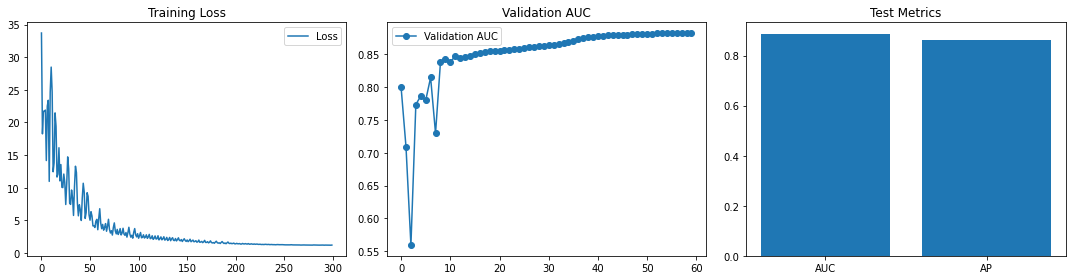

In [24]:
import torch
import time
import matplotlib.pyplot as plt

def main_link_prediction():
    configurations = [
        {
            'model_type': 'DMAHGT',
            'dataset': 'MovieLens100K',
            'num_layers': 3,
            'heads': 1,
            'hidden_dim': 128,
            'embedding_dim': 128,
            'dropout': 0.3,
            'epochs': 300,
            'optimizer': 'adam',
            'weight_decay': 1e-5,
            'learning_rate': 0.001,
            'num_relation_types': 1,
            'use_temporal': True,
            'use_features': True,
            'num_users':943,
            'num_movies':1682
            
        }
    ]

    for config_dict in configurations:

        config = Config(config_dict)

        device = torch.device(
            'cuda'
            if torch.cuda.is_available()
            else 'cpu'
        )

        print(f"Using device: {device}")

        print("\n" + "=" * 60)
        print("STEP 1: Loading MovieLens Dataset")
        print("=" * 60)

        data_path = download_and_extract_movielens()

        heterogeneous_data, user_feat_dim, movie_feat_dim = (
            load_movielens_heterogeneous(
                data_path,
                use_features=config.use_features,
                use_temporal=config.use_temporal
            )
        )

        config.user_feat_dim = user_feat_dim
        config.movie_feat_dim = movie_feat_dim

        heterogeneous_data = heterogeneous_data.to(device)

        print("\n" + "=" * 60)
        print("STEP 3: Preparing Data for Link Prediction")
        print("=" * 60)

        heterogeneous_data = prepare_link_prediction_data(heterogeneous_data)

        model_args = {
            'device': device,
            'hidden_size': config.hidden_dim,
            'num_layers': config.num_layers,
            'dropout': config.dropout
        }

        model = DMA_HGT(
            heterogeneous_data,
            model_args
        ).to(device)

        print("\n" + "=" * 60)
        print("STEP 4: Training DMAHGT")
        print("=" * 60)

        start_time = time.time()

        (
            val_aucs,
            losses,
            best_model,
            test_metrics
        ) = train_link_prediction_model(
            heterogeneous_data,
            model,
            config
        )

        end_time = time.time()

        elapsed_time = (
            end_time - start_time
        )

        print("\n" + "=" * 60)
        print("FINAL RESULTS")
        print("=" * 60)

        print(
            f"AUC: {test_metrics['auc']:.4f}"
        )

        print(
            f"AP: {test_metrics['ap']:.4f}"
        )

        rec_metrics = (
            evaluate_recommendation_clean(
                best_model,
                heterogeneous_data
            )
        )

        print(
            f"HR@5: {rec_metrics['HR@5']:.4f}"
        )

        print(
            f"HR@10: {rec_metrics['HR@10']:.4f}"
        )

        print(
            f"HR@20: {rec_metrics['HR@20']:.4f}"
        )

        print(
            f"NDCG@5: {rec_metrics['NDCG@5']:.4f}"
        )

        print(
            f"NDCG@10: {rec_metrics['NDCG@10']:.4f}"
        )

        print(
            f"NDCG@20: {rec_metrics['NDCG@20']:.4f}"
        )

        print(
            f"MRR: {rec_metrics['MRR']:.4f}"
        )

        print(
            f"Time Taken: {elapsed_time:.2f} seconds"
        )

        plt.figure(
            figsize=(15, 4)
        )

        plt.subplot(1, 3, 1)

        plt.plot(
            losses,
            label="Loss"
        )

        plt.title(
            "Training Loss"
        )

        plt.legend()

        plt.subplot(1, 3, 2)

        plt.plot(
            val_aucs,
            marker='o',
            label='Validation AUC'
        )

        plt.title(
            "Validation AUC"
        )

        plt.legend()

        plt.subplot(1, 3, 3)

        plt.bar(
            ['AUC', 'AP'],
            [
                test_metrics['auc'],
                test_metrics['ap']
            ]
        )

        plt.title(
            "Test Metrics"
        )

        plt.tight_layout()

        plt.show()

if __name__ == '__main__':
    main_link_prediction()